### Face Detection using OpenCV

This code snippet uses OpenCV's Haar Cascade classifier to detect faces in an image.

**Before running:**
1. **Upload an image:** Make sure you have an image file (e.g., `face.jpg`) in your Colab environment or update the `image_path` variable to point to your image.
2. **Download Haar Cascade:** The code will attempt to download the `haarcascade_frontalface_default.xml` file, which is necessary for face detection.

The detected faces will be outlined with rectangles, and the resulting image will be displayed.

haarcascade_frontalface_default.xml already exists.


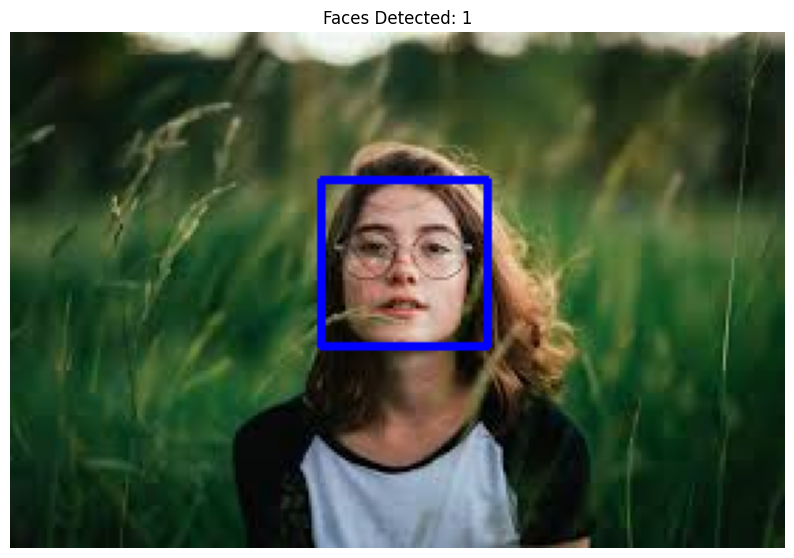

In [2]:
# Install OpenCV if not already installed (uncomment the line below if needed)
# !pip install opencv-python

import cv2
import urllib.request
import os
import matplotlib.pyplot as plt

# --- Step 1: Download Haar Cascade Classifier ---
# The Haar cascade XML file is needed to detect faces.
# We'll download it if it's not already present.

cascade_url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
cascade_filename = "haarcascade_frontalface_default.xml"

if not os.path.exists(cascade_filename):
    print(f"Downloading {cascade_filename}...")
    urllib.request.urlretrieve(cascade_url, cascade_filename)
    print("Download complete.")
else:
    print(f"{cascade_filename} already exists.")

# Load the cascade classifier
face_cascade = cv2.CascadeClassifier(cascade_filename)

# --- Step 2: Load an image ---
# Make sure you have an image file in your Colab environment
# For example, upload 'face.jpg' or change this path.
image_path = 'human.jfif' # Replace with your image file name

if not os.path.exists(image_path):
    print(f"Error: Image file '{image_path}' not found. Please upload it or change the 'image_path' variable.")
else:
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error: Could not load image from '{image_path}'. Check if it's a valid image file.")
    else:
        # Convert the image to grayscale, which is required for face detection
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # --- Step 3: Detect faces ---
        # detectMultiScale searches for objects of different sizes in the input image.
        # The detected objects are returned as a list of rectangles.
        # - scaleFactor: Parameter specifying how much the image size is reduced at each image scale.
        # - minNeighbors: Parameter specifying how many neighbors each candidate rectangle should have to retain it.
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

        # --- Step 4: Draw rectangles around the detected faces ---
        for (x, y, w, h) in faces:
            cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2) # Blue rectangle with thickness 2

        # --- Step 5: Display the result ---
        # Convert BGR image to RGB for displaying with matplotlib
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 8))
        plt.imshow(img_rgb)
        plt.title(f'Faces Detected: {len(faces)}')
        plt.axis('off') # Hide axes ticks and labels
        plt.show()
